# Credit Risk Predictor — Using the Pre-Trained Model
---
**This notebook loads the model you already trained in Parts 4.1–4.9.**  
No retraining. No waiting. Just load and predict.

### Before running this notebook, make sure you have run:
| Notebook | Creates |
|---|---|
| `Part4_1_Setup_and_Load_Data.ipynb` | `preprocessing_meta.pkl` |
| `Part4_6_Gradient_Boosting.ipynb` | `model_gbm.pkl` |
| `Part4_7_Model_Comparison_Selection.ipynb` | `model_selection.json` |
| `Part4_9_Artefacts_and_Inference.ipynb` | `best_model.pkl`, `inference_config.pkl` |

### All files must be in the **same folder** as this notebook.

---
**Workflow:**
1. Run cells 1–3 once — loads your trained model
2. Go to cell 4 — enter any person's details
3. Run cell 4 — get instant prediction + visual card
4. Change values and run again for a new person

## Cell 1 — Load Your Pre-Trained Model

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib, json, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# ── Check required files exist ────────────────────────────────────
required = {
    "best_model.pkl"       : "Trained model (from Part 4.9)",
    "inference_config.pkl" : "Preprocessing params (from Part 4.9)",
}

print("Checking required files...")
all_found = True
for fname, desc in required.items():
    exists = Path(fname).exists()
    icon   = "OK" if exists else "MISSING"
    size   = f"{Path(fname).stat().st_size/1024:.0f} KB" if exists else ""
    print(f"  [{icon}]  {fname:<30}  {size:<10}  {desc}")
    if not exists:
        all_found = False

if not all_found:
    print()
    print("ERROR: Some files are missing.")
    print("Please run the Part 4 notebooks first, then put all .pkl files")
    print("in the same folder as this notebook.")
else:
    print()
    print("All files found — loading model...")

    # ── Load ─────────────────────────────────────────────────────
    model  = joblib.load("best_model.pkl")
    config = joblib.load("inference_config.pkl")

    # ── Print model info ─────────────────────────────────────────
    print()
    print("=" * 55)
    print("  MODEL LOADED SUCCESSFULLY")
    print("=" * 55)
    print(f"  Model type        : {config['model_name']}")
    print(f"  Test AUC          : {config['test_auc']:.4f}")
    print(f"  Avg Precision     : {config['test_ap']:.4f}")
    print(f"  KS Statistic      : {config['ks']:.4f}")
    print(f"  Gini Coefficient  : {config['gini']:.4f}")
    print(f"  CV AUC            : {config['cv_mean']:.4f}")
    print(f"  Decision threshold: {config['opt_thresh']:.4f} ({config['opt_thresh']*100:.1f}%)")
    print(f"  Total features    : {config['n_features']}")
    print("=" * 55)

Checking required files...
  [OK]  best_model.pkl                  7 KB        Trained model (from Part 4.9)
  [OK]  inference_config.pkl            6 KB        Preprocessing params (from Part 4.9)

All files found — loading model...

  MODEL LOADED SUCCESSFULLY
  Model type        : Logistic Regression
  Test AUC          : 0.8575
  Avg Precision     : 0.2397
  KS Statistic      : 0.5938
  Gini Coefficient  : 0.7149
  CV AUC            : 0.8465
  Decision threshold: 0.5463 (54.6%)
  Total features    : 198


## Cell 2 — Set Up Preprocessing
*Run once.*

In [5]:
def preprocess_single(person_data: dict) -> np.ndarray:
    """
    Apply the exact same preprocessing pipeline used during training.
    Takes a dict of feature values, returns a ready-to-score numpy array.
    """
    num_cols  = config["num_cols"]
    cat_cols  = config["cat_cols"]
    flag_cols = config["flag_cols"]
    medians   = pd.Series(config["medians"])
    modes     = config["modes"]
    feat_cols = config["feature_cols_final"]

    # Build a single-row DataFrame
    row = {}
    for col in num_cols:
        val = person_data.get(col, None)
        row[col] = np.nan if (val is None) else float(val)
    for col in cat_cols:
        val = person_data.get(col, None)
        row[col] = None if (val is None) else str(val)

    df = pd.DataFrame([row])

    # Step 1: Missingness flags
    for col in flag_cols:
        if col in df.columns:
            df[f"{col}_is_missing"] = df[col].isnull().astype(np.int8)

    # Step 2: Median imputation
    df[num_cols] = df[num_cols].fillna(medians)

    # Step 3: Categorical encoding
    if cat_cols:
        for c in cat_cols:
            df[c] = df[c].fillna(modes.get(c, "MISSING"))
        df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    # Step 4: Align to training schema
    for c in feat_cols:
        if c not in df.columns:
            df[c] = 0

    X = df[feat_cols].values.astype(np.float32)
    nan_left = np.isnan(X).sum()
    if nan_left > 0:
        X = np.nan_to_num(X, nan=0.0)

    return X
print("Preprocessing function ready")
print(f"  Expected input features  : {len(config['num_cols'])} numeric + {len(config['cat_cols'])} categorical")
print(f"  After preprocessing      : {config['n_features']} features")
print(f"  Missingness flags added  : {len(config['flag_cols'])}")
print(f"  OHE dummy columns        : {config['n_features'] - len(config['num_cols']) - len(config['flag_cols'])}")

Preprocessing function ready
  Expected input features  : 98 numeric + 2 categorical
  After preprocessing      : 198 features
  Missingness flags added  : 79
  OHE dummy columns        : 21


## Cell 3 — Prediction Engine
*Run once.*

In [6]:
def predict(person_data: dict, show_card: bool = True) -> dict:
    """
    Score a new person using the pre-trained model.

    Parameters
    ----------
    person_data : dict
        Feature values. Keys = feature names from the training data.
        Set any value to None if unknown -- it will be imputed automatically.

    show_card : bool
        If True, prints a text result card and plots a visual card.

    Returns
    -------
    dict: probability, risk_band, decision, high_risk_flag
    """
    opt_thresh    = config["opt_thresh"]
    model_name    = config["model_name"]

    # Preprocess and score
    X     = preprocess_single(person_data)
    prob  = float(model.predict_proba(X)[0, 1])
    flag  = int(prob >= opt_thresh)

    # Risk band and decision
    if prob < 0.05:
        band, decision, color = "LOW",       "APPROVE",                "#2e7d32"
    elif prob < 0.15:
        band, decision, color = "MEDIUM",    "APPROVE with monitoring", "#f57c00"
    elif prob < 0.30:
        band, decision, color = "HIGH",      "REVIEW manually",        "#d84315"
    else:
        band, decision, color = "VERY HIGH", "DECLINE",                "#b71c1c"

    # Count what was provided vs imputed
    n_provided = sum(1 for k in config["num_cols"] + config["cat_cols"]
                     if person_data.get(k) is not None)
    n_imputed  = len(config["num_cols"]) + len(config["cat_cols"]) - n_provided

    if show_card:
        # ── Text card ────────────────────────────────────────────
        print("=" * 58)
        print(f"  CREDIT DEFAULT RISK PREDICTION  ({model_name})")
        print("=" * 58)
        print(f"  Default Probability  :  {prob*100:>7.3f}%")
        print(f"  Decision Threshold   :  {opt_thresh*100:>7.3f}%")
        print(f"  Risk Band            :  {band}")
        print(f"  Decision             :  {decision}")
        print(f"  High Risk Flag       :  {'YES *** FLAGGED ***' if flag else 'NO'}")
        print("=" * 58)
        print(f"  Features provided    :  {n_provided}")
        print(f"  Features imputed     :  {n_imputed}  (median from training data)")
        print("=" * 58)
        print()

        # ── Risk gauge (ASCII) ───────────────────────────────────
        filled = int(prob * 50)
        bar    = "#" * filled + "-" * (50 - filled)
        thresh_pos = int(opt_thresh * 50)
        gauge = list(bar)
        if thresh_pos < len(gauge):
            gauge[thresh_pos] = "|"
        print(f"  Risk: [{''.join(gauge)}]  {prob*100:.1f}%")
        print(f"         0%         25%         50%         75%        100%")
        print(f"         {'|' + ' '*19 + '|' + ' '*19 + '|' + ' '*19 + '|'}")
        print(f"         Low      Medium       High      Very High")
        print()

        # ── Visual card ──────────────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
        fig.patch.set_facecolor("#f5f5f5")
        fig.suptitle(f"Credit Risk Prediction Card  |  Model: {model_name}",
                     fontsize=12, fontweight="bold", color="#333", y=1.02)

        # Panel A: Probability gauge
        ax = axes[0]
        ax.set_facecolor("#f5f5f5"); ax.axis("off")
        ax.set_xlim(0,1); ax.set_ylim(0,1)

        # Gradient background bar (4 risk zones)
        for x0, x1, c in [(0,0.05,"#c8e6c9"),(0.05,0.15,"#ffe0b2"),
                           (0.15,0.30,"#ffccbc"),(0.30,1.0,"#ffcdd2")]:
            ax.barh(0.50, x1-x0, 0.18, left=x0, color=c, align="center", zorder=1)
        # Filled probability
        ax.barh(0.50, prob, 0.14, left=0, color=color, align="center", zorder=2, alpha=0.9)
        # Threshold marker
        ax.axvline(opt_thresh, ymin=0.38, ymax=0.62,
                   color="black", lw=2.5, zorder=3)
        ax.text(opt_thresh, 0.73, f"Threshold{opt_thresh*100:.1f}%",
                ha="center", fontsize=8, color="#333", zorder=4)
        # Probability label
        ax.text(0.5, 0.88, "DEFAULT PROBABILITY",
                ha="center", fontsize=10, fontweight="bold",
                color="#444", transform=ax.transAxes)
        ax.text(0.5, 0.22, f"{prob*100:.2f}%",
                ha="center", fontsize=32, fontweight="bold",
                color=color, transform=ax.transAxes)
        ax.text(0.0, 0.37, "0%", ha="left",  fontsize=8, color="#888")
        ax.text(1.0, 0.37, "100%", ha="right", fontsize=8, color="#888")

        # Panel B: Risk band card
        ax = axes[1]
        ax.set_facecolor("#f5f5f5"); ax.axis("off")
        rect = mpatches.FancyBboxPatch((0.05,0.05), 0.90, 0.90,
                                        boxstyle="round,pad=0.02",
                                        facecolor=color, alpha=0.12,
                                        edgecolor=color, linewidth=2.5,
                                        transform=ax.transAxes)
        ax.add_patch(rect)
        ax.text(0.5, 0.85, "RISK BAND",
                ha="center", fontsize=10, color="#555",
                transform=ax.transAxes, fontweight="bold")
        ax.text(0.5, 0.62, band,
                ha="center", fontsize=28, fontweight="bold",
                color=color, transform=ax.transAxes)
        ax.text(0.5, 0.42, "DECISION",
                ha="center", fontsize=10, color="#555",
                transform=ax.transAxes, fontweight="bold")
        ax.text(0.5, 0.25, decision.upper(),
                ha="center", fontsize=11, fontweight="bold",
                color=color, transform=ax.transAxes)
        flag_txt = "HIGH RISK  FLAGGED" if flag else "NOT FLAGGED"
        flag_col = color if flag else "#2e7d32"
        ax.text(0.5, 0.10, flag_txt,
                ha="center", fontsize=9, fontweight="bold",
                color=flag_col, transform=ax.transAxes)

        # Panel C: Feature summary
        ax = axes[2]
        ax.set_facecolor("#f5f5f5"); ax.axis("off")
        ax.text(0.5, 0.97, "KEY INPUTS",
                ha="center", fontsize=10, fontweight="bold",
                color="#333", transform=ax.transAxes)
        provided_items = [(k, v) for k, v in person_data.items() if v is not None]
        y_pos = 0.88
        for k, v in provided_items[:12]:
            short_k = k.replace("repayment_history_","rph_").replace("utilization_","util_")
            short_k = short_k.replace("financial_situation_","fin_sit_").replace("recency_","rec_")
            ax.text(0.05, y_pos, f"{short_k}:",
                    ha="left", fontsize=8, color="#555", transform=ax.transAxes)
            ax.text(0.95, y_pos, str(v),
                    ha="right", fontsize=8, color="#222", fontweight="bold",
                    transform=ax.transAxes)
            y_pos -= 0.073
        if len(provided_items) > 12:
            ax.text(0.5, y_pos, f"... +{len(provided_items)-12} more",
                    ha="center", fontsize=8, color="#888", transform=ax.transAxes)
        ax.text(0.05, 0.05,
                f"Provided: {n_provided}  |  Imputed: {n_imputed}",
                ha="left", fontsize=8, color="#888", transform=ax.transAxes)

        plt.tight_layout()
        plt.show()

    return {
        "probability"    : round(prob, 6),
        "risk_band"      : band,
        "decision"       : decision,
        "high_risk_flag" : flag,
    }

print("predict() function ready")
print()
print("Usage:")
print("  result = predict(person)")
print()
print("Available features to set:")
print(f"  Numeric     : {len(config['num_cols'])} features (score_1, balance_1..24, utilization_1..18, etc.)")
print(f"  Categorical : {len(config['cat_cols'])} features -- {config['cat_cols']}")
print()
print("Categorical valid values:")
print("  financial_situation_4 : P1, P2, P3, P4, S1, S2, S3, S4, N1, N2, N3, N4, ND")
print("  financial_situation_5 : A, B, C, D, E, F, G, H")

predict() function ready

Usage:
  result = predict(person)

Available features to set:
  Numeric     : 98 features (score_1, balance_1..24, utilization_1..18, etc.)
  Categorical : 2 features -- ['financial_situation_4', 'financial_situation_5']

Categorical valid values:
  financial_situation_4 : P1, P2, P3, P4, S1, S2, S3, S4, N1, N2, N3, N4, ND
  financial_situation_5 : A, B, C, D, E, F, G, H


---
## Cell 4 — ENTER PERSON DETAILS HERE

**Edit the values below, then run this cell.**

### Feature guide (most important ones)
| Feature | Range | What it means |
|---|---|---|
| `score_1` | 437–1102 | Bureau credit score. **Higher = safer** |
| `utilization_1` to `_18` | 0–100+ | % of credit limit used. **Higher = riskier** |
| `repayment_history_1` to `_31` | 0–400 | Repayment behaviour. **Higher = better** |
| `recency_1` to `_12` | 0–800 | Months since a credit event. `None` = never happened |
| `balance_1` to `_24` | varies | Outstanding balances |
| `financial_situation_4` | P1/S1/N1/... | P=Positive, S=Standard, N=Negative |
| `financial_situation_5` | A/B/C/.../H | Financial situation category |

> **Set any feature to `None` if you don't have that information.**  
> The model will automatically use the training median for missing values.

  CREDIT DEFAULT RISK PREDICTION  (Logistic Regression)
  Default Probability  :   17.801%
  Decision Threshold   :   54.630%
  Risk Band            :  HIGH
  Decision             :  REVIEW manually
  High Risk Flag       :  NO
  Features provided    :  13
  Features imputed     :  87  (median from training data)

  Risk: [########-------------------|----------------------]  17.8%
         0%         25%         50%         75%        100%
         |                   |                   |                   |
         Low      Medium       High      Very High



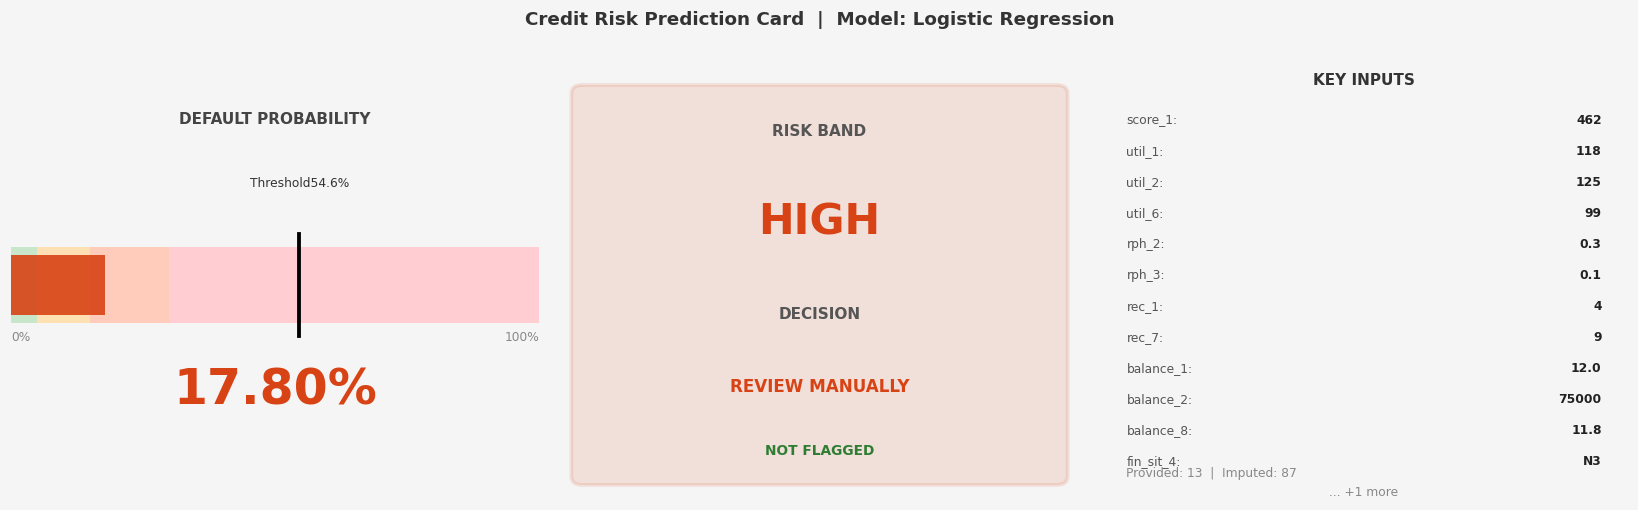

In [19]:
# ==============================================================
#   EDIT THESE VALUES — then Run this cell
# ==============================================================

# person = {

#     # ── Credit bureau score ────────────────────────────────
#     "score_1"                 : 470,    # 437 to 1102. Higher = safer.

#     # ── Credit utilization ─────────────────────────────────
#     "utilization_1"           : 75,     # % of credit used (0-100+)
#     "utilization_2"           : 70,     # second credit product
#     "utilization_3"           : None,   # None = not known / no product
#     "utilization_4"           : None,
#     "utilization_5"           : None,
#     "utilization_6"           : 55,
#     "utilization_7"           : None,
#     "utilization_8"           : None,
#     "utilization_9"           : None,
#     "utilization_10"          : None,
#     "utilization_11"          : None,
#     "utilization_12"          : None,
#     "utilization_13"          : None,
#     "utilization_14"          : None,
#     "utilization_15"          : None,
#     "utilization_16"          : None,
#     "utilization_17"          : None,
#     "utilization_18"          : None,

#     # ── Repayment history ──────────────────────────────────
#     "repayment_history_1"     : None,   # None = no history on this product
#     "repayment_history_2"     : 3.5,    # higher = better
#     "repayment_history_3"     : 2.0,
#     "repayment_history_4"     : None,
#     "repayment_history_5"     : None,
#     "repayment_history_6"     : None,
#     "repayment_history_7"     : None,
#     "repayment_history_8"     : None,
#     "repayment_history_9"     : None,
#     "repayment_history_10"    : None,
#     "repayment_history_11"    : None,
#     "repayment_history_12"    : None,

#     # ── Recency (months since last credit event) ───────────
#     "recency_1"               : 100,     # months since event. None = never happened
#     "recency_2"               : None,
#     "recency_3"               : None,
#     "recency_4"               : None,
#     "recency_5"               : None,
#     "recency_6"               : None,
#     "recency_7"               : 200,
#     "recency_8"               : None,
#     "recency_9"               : None,
#     "recency_10"              : None,
#     "recency_11"              : None,
#     "recency_12"              : None,

#     # ── Balances ───────────────────────────────────────────
#     "balance_1"               : 8.0,
#     "balance_2"               : 5000,
#     "balance_3"               : None,
#     "balance_4"               : None,
#     "balance_5"               : None,
#     "balance_6"               : None,
#     "balance_7"               : None,
#     "balance_8"               : 7.0,
#     "balance_9"               : None,
#     "balance_10"              : None,
#     "balance_11"              : None,
#     "balance_12"              : None,
#     "balance_13"              : None,
#     "balance_14"              : None,
#     "balance_15"              : None,
#     "balance_16"              : None,
#     "balance_17"              : None,
#     "balance_18"              : None,
#     "balance_19"              : None,
#     "balance_20"              : None,
#     "balance_21"              : None,
#     "balance_22"              : None,
#     "balance_23"              : None,
#     "balance_24"              : None,

#     # ── Credit limits ──────────────────────────────────────
#     "credit_limit_1"          : None,
#     "credit_limit_2"          : None,
#     "credit_limit_3"          : None,

#     # ── Financial situation (categorical) ─────────────────
#     # financial_situation_4 options:
#     #   P1, P2, P3, P4  (Positive - better)
#     #   S1, S2, S3, S4  (Standard)
#     #   N1, N2, N3, N4  (Negative - worse)
#     #   ND               (No Data)
#     "financial_situation_4"   : "P1",

#     # financial_situation_5 options: A, B, C, D, E, F, G, H
#     "financial_situation_5"   : "B",

#     # ── Other features (set to None to use training median) ─
#     "financial_situation_1"   : None,
#     "financial_situation_2"   : None,
#     "financial_situation_3"   : None,
#     "spend_behaviour_1"       : None,
#     "spend_behaviour_2"       : None,
#     "spend_behaviour_3"       : None,
#     "spend_behaviour_4"       : None,
#     "spend_behaviour_5"       : None,
#     "demand_for_credit_1"     : None,
# }
person = {
    "score_1"                 : 462,
    "utilization_1"           : 118,
    "utilization_2"           : 125,
    "utilization_6"           : 99,
    "repayment_history_2"     : 0.3,
    "repayment_history_3"     : 0.1,
    "repayment_history_4"     : None,
    "recency_1"               : 4,
    "recency_7"               : 9,
    "balance_1"               : 12.0,
    "balance_2"               : 75000,
    "balance_8"               : 11.8,
    "financial_situation_4"   : "N3",
    "financial_situation_5"   : "H",
    "demand_for_credit_1"     : None,
    "spend_behaviour_1"       : None,
}



# ── GET PREDICTION ────────────────────────────────────────────────
result = predict(person, show_card=True)

---
## Cell 5 — Compare Multiple People

Define several profiles and compare them side by side.

  Profile               Default %    Risk Band                   Decision
  ----------------------------------------------------------------------
  Low Risk                  1.21%          LOW                    APPROVE
  Medium Risk              23.75%         HIGH            REVIEW manually
  High Risk                54.41%    VERY HIGH                    DECLINE
  Very High Risk           44.75%    VERY HIGH                    DECLINE


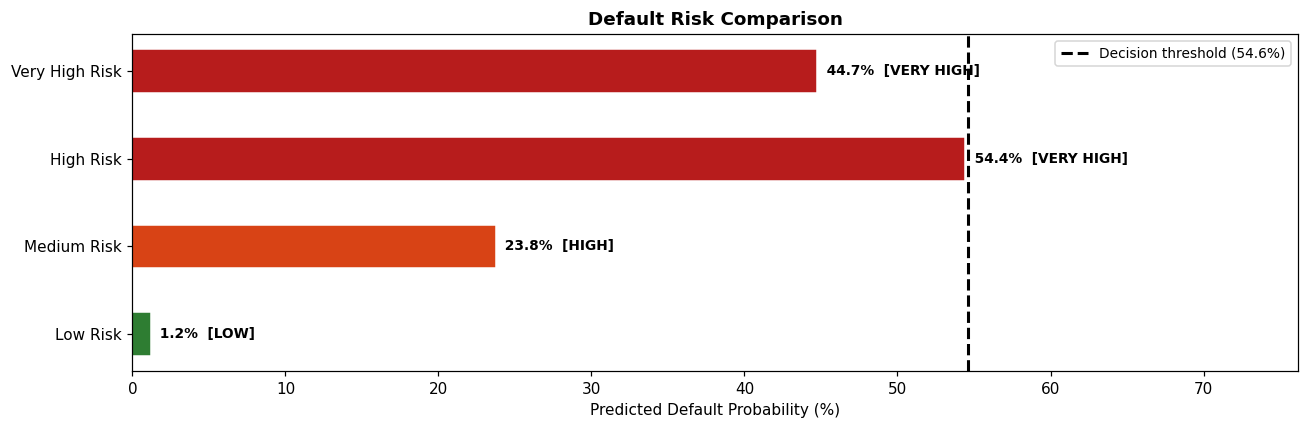

In [8]:
# ── Define profiles ──────────────────────────────────────────────
profiles = {
    "Low Risk": {
        "score_1": 900, "utilization_1": 10, "utilization_2": 12,
        "repayment_history_2": 9.0, "repayment_history_3": 7.0,
        "recency_1": 300, "recency_7": 500,
        "balance_1": 5.0, "balance_2": 500,
        "financial_situation_4": "P1", "financial_situation_5": "A",
    },
    "Medium Risk": {
        "score_1": 640, "utilization_1": 65, "utilization_2": 70,
        "repayment_history_2": 3.5, "repayment_history_3": 2.0,
        "recency_1": 48, "recency_7": 120,
        "balance_1": 9.0, "balance_2": 8000,
        "financial_situation_4": "S2", "financial_situation_5": "E",
    },
    "High Risk": {
        "score_1": 510, "utilization_1": 95, "utilization_2": 98,
        "repayment_history_2": 1.0, "repayment_history_3": 0.5,
        "recency_1": 12, "recency_7": 24,
        "balance_1": 12.0, "balance_2": 45000,
        "financial_situation_4": "N2", "financial_situation_5": "G",
    },
    "Very High Risk": {
        "score_1": 455, "utilization_1": 120, "utilization_2": 130,
        "repayment_history_2": 0.1, "repayment_history_3": None,
        "recency_1": 3, "recency_7": 6,
        "balance_1": 12.0, "balance_2": 90000,
        "financial_situation_4": "N4", "financial_situation_5": "H",
    },
}

# Predict silently
preds = {name: predict(data, show_card=False) for name, data in profiles.items()}

# Table
print("=" * 72)
print(f"  {'Profile':<18} {'Default %':>12} {'Risk Band':>12} {'Decision':>26}")
print("  " + "-" * 70)
band_colors = {"LOW":"green","MEDIUM":"darkorange","HIGH":"orangered","VERY HIGH":"red"}
for name, r in preds.items():
    print(f"  {name:<18} {r['probability']*100:>11.2f}% {r['risk_band']:>12} {r['decision']:>26}")
print("=" * 72)

# Visual bar chart
fig, ax = plt.subplots(figsize=(12, 4))
names  = list(preds.keys())
probs  = [preds[n]["probability"]*100 for n in names]
bcolors = [{"LOW":"#2e7d32","MEDIUM":"#f57c00",
             "HIGH":"#d84315","VERY HIGH":"#b71c1c"}[preds[n]["risk_band"]] for n in names]

bars = ax.barh(names, probs, color=bcolors, edgecolor="white", height=0.5)
ax.axvline(config["opt_thresh"]*100, color="black", linestyle="--", lw=2,
           label=f"Decision threshold ({config['opt_thresh']*100:.1f}%)")
ax.set_xlabel("Predicted Default Probability (%)")
ax.set_title("Default Risk Comparison", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
for bar, val, name in zip(bars, probs, names):
    band = preds[name]["risk_band"]
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f" {val:.1f}%  [{band}]",
            va="center", fontsize=9, fontweight="bold")
ax.set_xlim(0, max(probs) * 1.4)
plt.tight_layout()
plt.show()